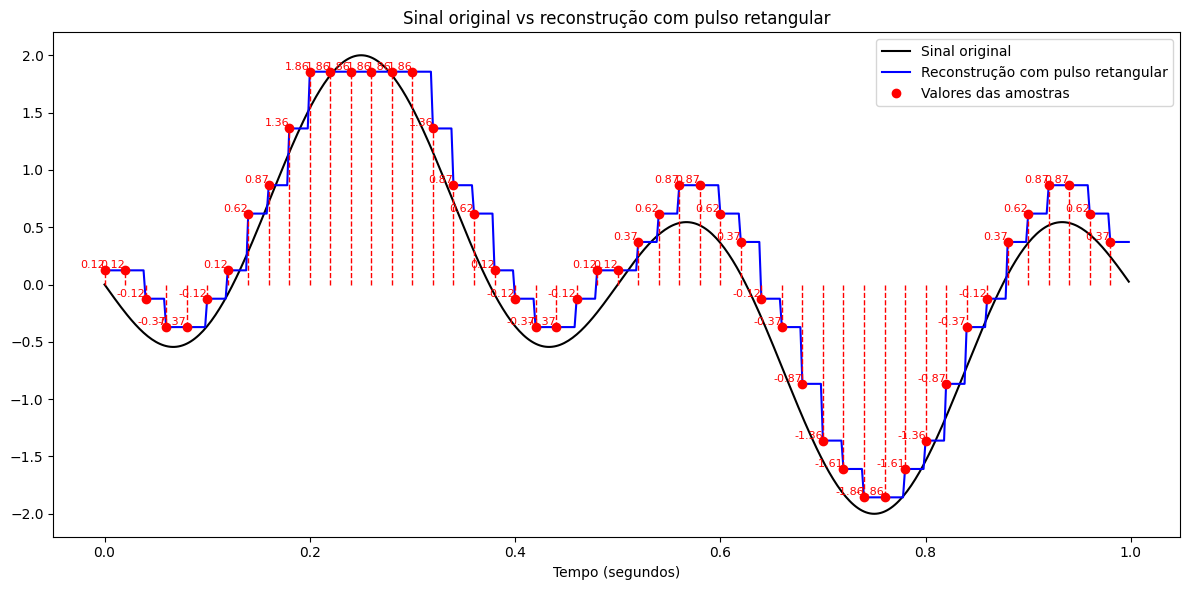

Quantidade de níveis de quantização: 16
Valores possíveis de quantização (truncados): [-1.85 -1.6  -1.36 -1.11 -0.86 -0.61 -0.37 -0.12  0.12  0.37  0.61  0.86
  1.11  1.36  1.6   1.85]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft

def uniquan(sig_in, L):
    sig_pmax = np.max(sig_in)
    sig_nmax = np.min(sig_in)
    Delta = (sig_pmax - sig_nmax) / L
    q_level = np.linspace(sig_nmax + Delta / 2, sig_pmax - Delta / 2, L)
    sigp = (sig_in - sig_nmax) / Delta + 0.5
    qindex = np.round(sigp).astype(int)
    qindex = np.clip(qindex, 0, L - 1)
    q_out = q_level[qindex]
    SQNR = 20 * np.log10(np.linalg.norm(sig_in) / np.linalg.norm(sig_in - q_out))
    return q_out, Delta, SQNR, q_level

def sampandquant(sig_in, L, td, ts):
    if ts % td == 0:
        nfac = int(ts / td)
        p_zoh = np.ones(nfac)
        s_out = sig_in[::nfac]
        sq_out, Delta, SQNR, q_level = uniquan(s_out, L)
        s_out = np.repeat(s_out, nfac)
        sqh_out = np.kron(sq_out, p_zoh)
        sq_out = np.repeat(sq_out, nfac)
        return s_out, sq_out, sqh_out, Delta, SQNR, q_level
    else:
        raise ValueError("Erro! ts/td não é um inteiro!")

# Parâmetros e sinal original
td = 0.002
t = np.arange(0, 1.0, td)
xsig = np.sin(2 * np.pi * t) - np.sin(6 * np.pi * t)
Lsig = len(xsig)

ts = 0.02
Nfactor = int(ts / td)

# Amostragem e quantização
s_out, sq_out, sqh_out, Delta, SQNR, q_level = sampandquant(xsig, 16, td, ts)

# Reconstrução não ideal
ZOH = np.ones(Nfactor)
s_ni = np.kron(sq_out[::Nfactor], ZOH)

# Gráficos
plt.figure(figsize=(12, 6))

# Gráfico: Sinal original vs reconstrução com pulso retangular
plt.plot(t, xsig, 'k', label='Sinal original')
plt.plot(t, s_ni[:Lsig], 'b', label='Reconstrução com pulso retangular')

# Adiciona bolinhas vermelhas, números e linhas tracejadas nas quinas da escadinha
for i in range(len(sq_out) // Nfactor):
    x_pos = t[i * Nfactor]
    y_pos = sq_out[i * Nfactor]
    plt.plot(x_pos, y_pos, 'ro', label='Valores das amostras' if i == 0 else "")  # Bolinhas vermelhas
    plt.vlines(x_pos, 0, y_pos, colors='red', linestyles='dashed', linewidth=1)
    plt.text(x_pos, y_pos, f'{y_pos:.2f}', verticalalignment='bottom', horizontalalignment='right', fontsize=8, color='red')

plt.xlabel('Tempo (segundos)')
plt.title('Sinal original vs reconstrução com pulso retangular')
plt.legend()

plt.tight_layout()
plt.show()

# Printar quantidade de níveis e pool dos níveis
q_level_trunc = np.trunc(q_level * 100) / 100  # Truncar para duas casas decimais
print(f"Quantidade de níveis de quantização: {len(q_level_trunc)}")
print(f"Valores possíveis de quantização (truncados): {q_level_trunc}")


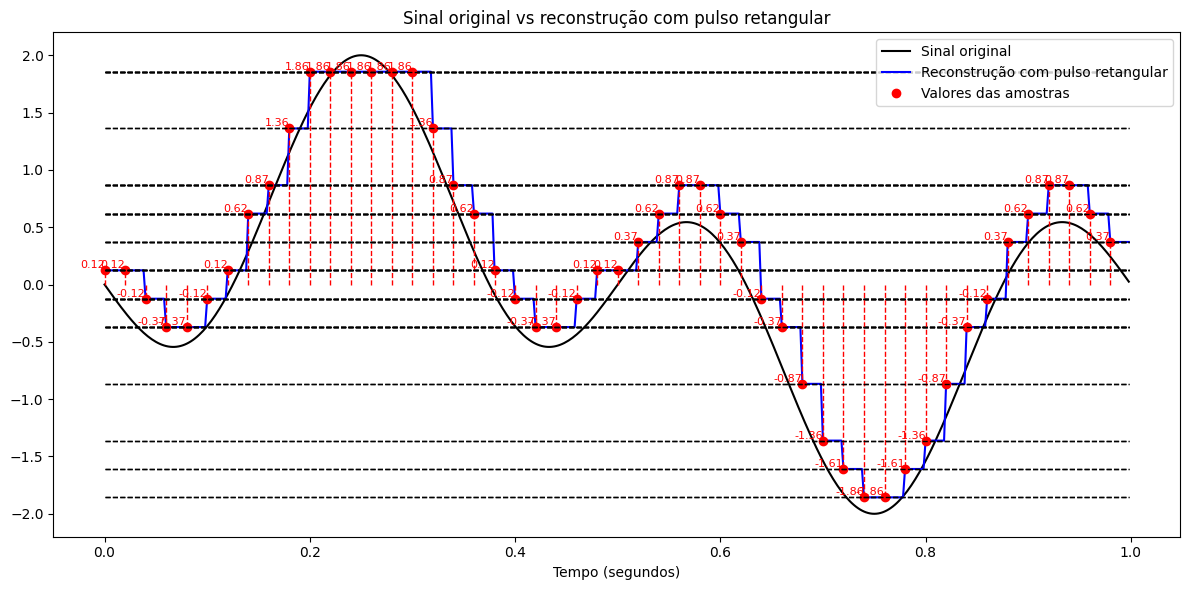

Quantidade de níveis de quantização: 16
Valores possíveis de quantização (truncados): [-1.85 -1.6  -1.36 -1.11 -0.86 -0.61 -0.37 -0.12  0.12  0.37  0.61  0.86
  1.11  1.36  1.6   1.85]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft

def uniquan(sig_in, L):
    sig_pmax = np.max(sig_in)
    sig_nmax = np.min(sig_in)
    Delta = (sig_pmax - sig_nmax) / L
    q_level = np.linspace(sig_nmax + Delta / 2, sig_pmax - Delta / 2, L)
    sigp = (sig_in - sig_nmax) / Delta + 0.5
    qindex = np.round(sigp).astype(int)
    qindex = np.clip(qindex, 0, L - 1)
    q_out = q_level[qindex]
    SQNR = 20 * np.log10(np.linalg.norm(sig_in) / np.linalg.norm(sig_in - q_out))
    return q_out, Delta, SQNR, q_level

def sampandquant(sig_in, L, td, ts):
    if ts % td == 0:
        nfac = int(ts / td)
        p_zoh = np.ones(nfac)
        s_out = sig_in[::nfac]
        sq_out, Delta, SQNR, q_level = uniquan(s_out, L)
        s_out = np.repeat(s_out, nfac)
        sqh_out = np.kron(sq_out, p_zoh)
        sq_out = np.repeat(sq_out, nfac)
        return s_out, sq_out, sqh_out, Delta, SQNR, q_level
    else:
        raise ValueError("Erro! ts/td não é um inteiro!")

# Parâmetros e sinal original
td = 0.002
t = np.arange(0, 1.0, td)
xsig = np.sin(2 * np.pi * t) - np.sin(6 * np.pi * t)
Lsig = len(xsig)

ts = 0.02
Nfactor = int(ts / td)

# Amostragem e quantização
s_out, sq_out, sqh_out, Delta, SQNR, q_level = sampandquant(xsig, 16, td, ts)

# Reconstrução não ideal
ZOH = np.ones(Nfactor)
s_ni = np.kron(sq_out[::Nfactor], ZOH)

# Gráficos
plt.figure(figsize=(12, 6))

# Gráfico: Sinal original vs reconstrução com pulso retangular
plt.plot(t, xsig, 'k', label='Sinal original')
plt.plot(t, s_ni[:Lsig], 'b', label='Reconstrução com pulso retangular')

# Adiciona bolinhas vermelhas, números e linhas tracejadas nas quinas da escadinha
for i in range(len(sq_out) // Nfactor):
    x_pos = t[i * Nfactor]
    y_pos = sq_out[i * Nfactor]
    plt.plot(x_pos, y_pos, 'ro', label='Valores das amostras' if i == 0 else "")  # Bolinhas vermelhas
    plt.vlines(x_pos, 0, y_pos, colors='red', linestyles='dashed', linewidth=1)
    plt.hlines(y_pos, t[0], t[-1], colors='black', linestyles='dashed', linewidth=1)
    plt.text(x_pos, y_pos, f'{y_pos:.2f}', verticalalignment='bottom', horizontalalignment='right', fontsize=8, color='red')

plt.xlabel('Tempo (segundos)')
plt.title('Sinal original vs reconstrução com pulso retangular')
plt.legend()

plt.tight_layout()
plt.show()

# Printar quantidade de níveis e pool dos níveis
q_level_trunc = np.trunc(q_level * 100) / 100  # Truncar para duas casas decimais
print(f"Quantidade de níveis de quantização: {len(q_level_trunc)}")
print(f"Valores possíveis de quantização (truncados): {q_level_trunc}")


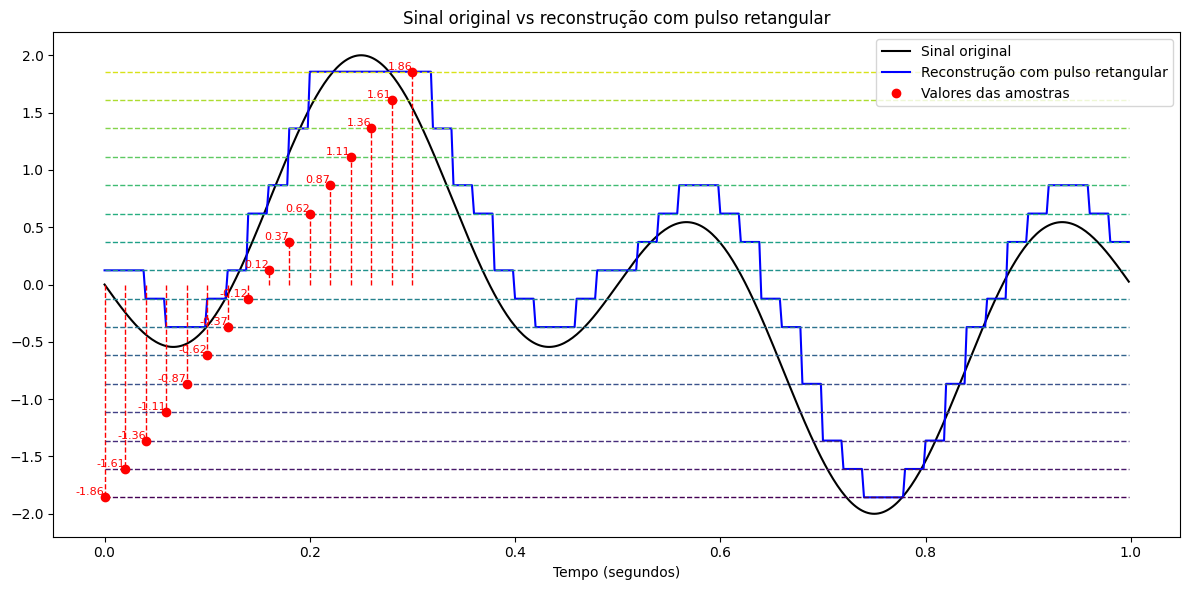

Quantidade de níveis de quantização: 16
Valores possíveis de quantização (truncados): [-1.85 -1.6  -1.36 -1.11 -0.86 -0.61 -0.37 -0.12  0.12  0.37  0.61  0.86
  1.11  1.36  1.6   1.85]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft

def uniquan(sig_in, L):
    sig_pmax = np.max(sig_in)
    sig_nmax = np.min(sig_in)
    Delta = (sig_pmax - sig_nmax) / L
    q_level = np.linspace(sig_nmax + Delta / 2, sig_pmax - Delta / 2, L)
    sigp = (sig_in - sig_nmax) / Delta + 0.5
    qindex = np.round(sigp).astype(int)
    qindex = np.clip(qindex, 0, L - 1)
    q_out = q_level[qindex]
    SQNR = 20 * np.log10(np.linalg.norm(sig_in) / np.linalg.norm(sig_in - q_out))
    return q_out, Delta, SQNR, q_level

def sampandquant(sig_in, L, td, ts):
    if ts % td == 0:
        nfac = int(ts / td)
        p_zoh = np.ones(nfac)
        s_out = sig_in[::nfac]
        sq_out, Delta, SQNR, q_level = uniquan(s_out, L)
        s_out = np.repeat(s_out, nfac)
        sqh_out = np.kron(sq_out, p_zoh)
        sq_out = np.repeat(sq_out, nfac)
        return s_out, sq_out, sqh_out, Delta, SQNR, q_level
    else:
        raise ValueError("Erro! ts/td não é um inteiro!")

# Parâmetros e sinal original
td = 0.002
t = np.arange(0, 1.0, td)
xsig = np.sin(2 * np.pi * t) - np.sin(6 * np.pi * t)
Lsig = len(xsig)

ts = 0.02
Nfactor = int(ts / td)

# Amostragem e quantização
s_out, sq_out, sqh_out, Delta, SQNR, q_level = sampandquant(xsig, 16, td, ts)

# Reconstrução não ideal
ZOH = np.ones(Nfactor)
s_ni = np.kron(sq_out[::Nfactor], ZOH)

# Gráficos
plt.figure(figsize=(12, 6))

# Gráfico: Sinal original vs reconstrução com pulso retangular
plt.plot(t, xsig, 'k', label='Sinal original')
plt.plot(t, s_ni[:Lsig], 'b', label='Reconstrução com pulso retangular')

# Adiciona bolinhas vermelhas, números e linhas tracejadas horizontais para todos os níveis
for i, y_pos in enumerate(q_level):
    color = plt.cm.viridis(i / len(q_level))  # Usando um colormap para cores diferentes
    plt.hlines(y_pos, t[0], t[-1], colors=color, linestyles='dashed', linewidth=1)
    plt.plot(t[i * Nfactor], y_pos, 'ro', label='Valores das amostras' if i == 0 else "")  # Bolinhas vermelhas
    plt.vlines(t[i * Nfactor], 0, y_pos, colors='red', linestyles='dashed', linewidth=1)
    plt.text(t[i * Nfactor], y_pos, f'{y_pos:.2f}', verticalalignment='bottom', horizontalalignment='right', fontsize=8, color='red')

plt.xlabel('Tempo (segundos)')
plt.title('Sinal original vs reconstrução com pulso retangular')
plt.legend()

plt.tight_layout()
plt.show()

# Printar quantidade de níveis e pool dos níveis
q_level_trunc = np.trunc(q_level * 100) / 100  # Truncar para duas casas decimais
print(f"Quantidade de níveis de quantização: {len(q_level_trunc)}")
print(f"Valores possíveis de quantização (truncados): {q_level_trunc}")


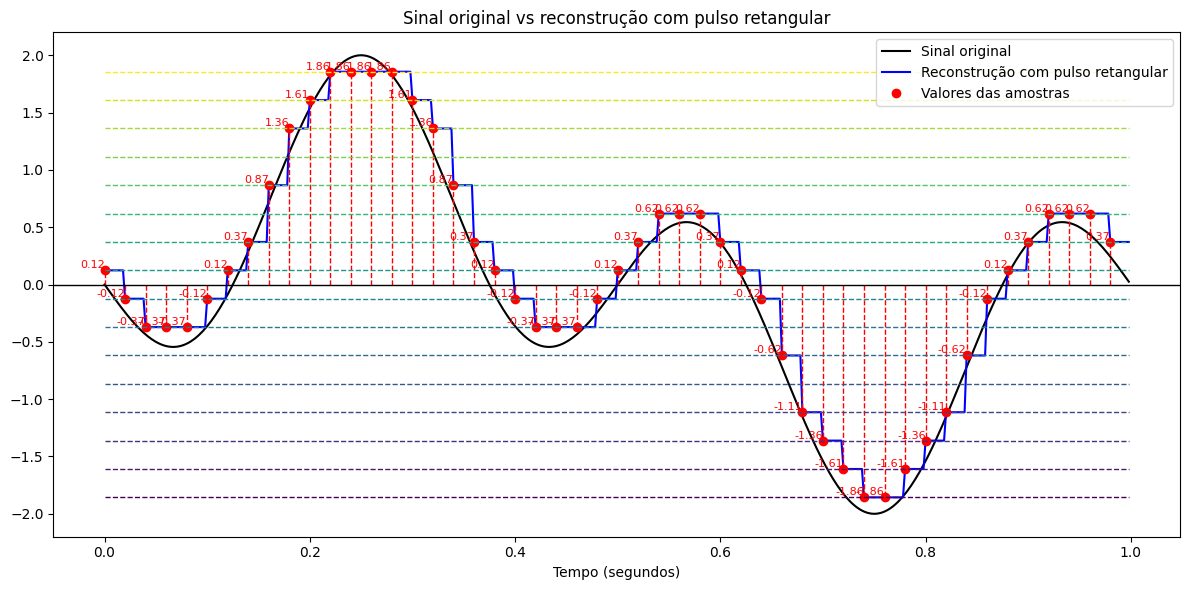

Quantidade de níveis de quantização: 16
Valores possíveis de quantização (truncados): [-1.85 -1.6  -1.36 -1.11 -0.86 -0.61 -0.37 -0.12  0.12  0.37  0.61  0.86
  1.11  1.36  1.6   1.85]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft

def uniquan(sig_in, L):
    sig_pmax = np.max(sig_in)
    sig_nmax = np.min(sig_in)
    Delta = (sig_pmax - sig_nmax) / L
    q_level = np.linspace(sig_nmax + Delta / 2, sig_pmax - Delta / 2, L)
    sigp = (sig_in - sig_nmax) / Delta + 0.5
    qindex = np.round(sigp).astype(int)
    qindex = np.clip(qindex, 0, L - 1)
    q_out = q_level[qindex]
    SQNR = 20 * np.log10(np.linalg.norm(sig_in) / np.linalg.norm(sig_in - q_out))
    return q_out, Delta, SQNR, q_level

def sampandquant(sig_in, L, td, ts):
    if ts % td == 0:
        nfac = int(ts / td)
        p_zoh = np.ones(nfac)
        s_out = sig_in[::nfac]
        sq_out, Delta, SQNR, q_level = uniquan(s_out, L)
        s_out = np.repeat(s_out, nfac)
        sqh_out = np.kron(sq_out, p_zoh)
        sq_out = np.repeat(sq_out, nfac)
        return s_out, sq_out, sqh_out, Delta, SQNR, q_level
    else:
        raise ValueError("Erro! ts/td não é um inteiro!")

# Parâmetros e sinal original
td = 0.002
t = np.arange(0, 1.0, td)
xsig = np.sin(2 * np.pi * t) - np.sin(6 * np.pi * t)
Lsig = len(xsig)

ts = 0.02
Nfactor = int(ts / td)

# Amostragem e quantização
s_out, sq_out, sqh_out, Delta, SQNR, q_level = sampandquant(xsig, 16, td, ts)

# Reconstrução não ideal
ZOH = np.ones(Nfactor)
s_ni = np.kron(sq_out[::Nfactor], ZOH)

# Gráficos
plt.figure(figsize=(12, 6))

# Gráfico: Sinal original vs reconstrução com pulso retangular
plt.plot(t, xsig, 'k', label='Sinal original')
plt.plot(t, s_ni[:Lsig], 'b', label='Reconstrução com pulso retangular')

# Adiciona bolinhas vermelhas, números, linhas tracejadas e linha contínua no zero
for i in range(len(sq_out) // Nfactor):
    x_pos = t[i * Nfactor]
    y_pos = sq_out[i * Nfactor]
    plt.plot(x_pos, y_pos, 'ro', label='Valores das amostras' if i == 0 else "")  # Bolinhas vermelhas
    plt.vlines(x_pos, 0, y_pos, colors='red', linestyles='dashed', linewidth=1)
    plt.text(x_pos, y_pos, f'{y_pos:.2f}', verticalalignment='bottom', horizontalalignment='right', fontsize=8, color='red')

# Adiciona linhas horizontais tracejadas para todos os níveis de quantização
for y_pos in q_level:
    color = plt.cm.viridis((y_pos - np.min(q_level)) / (np.max(q_level) - np.min(q_level)))
    plt.hlines(y_pos, t[0], t[-1], colors=color, linestyles='dashed', linewidth=1)

# Adiciona linha contínua preta no zero
plt.axhline(0, color='black', linestyle='-', linewidth=1)

plt.xlabel('Tempo (segundos)')
plt.title('Sinal original vs reconstrução com pulso retangular')
plt.legend()

plt.tight_layout()
plt.show()

# Printar quantidade de níveis e pool dos níveis
q_level_trunc = np.trunc(q_level * 100) / 100  # Truncar para duas casas decimais
print(f"Quantidade de níveis de quantização: {len(q_level_trunc)}")
print(f"Valores possíveis de quantização (truncados): {q_level_trunc}")
